In [15]:
import pandas as pd
df = pd.read_csv('Datasets/Advertising.csv')
print(df.head(5))

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [16]:
df.columns

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [17]:
df.shape

(200, 5)

In [18]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


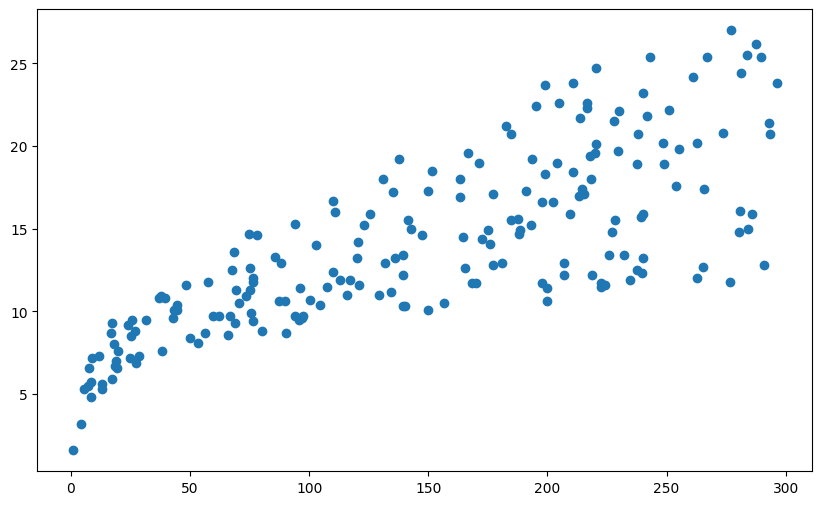

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['TV'], df['sales'])
plt.show()



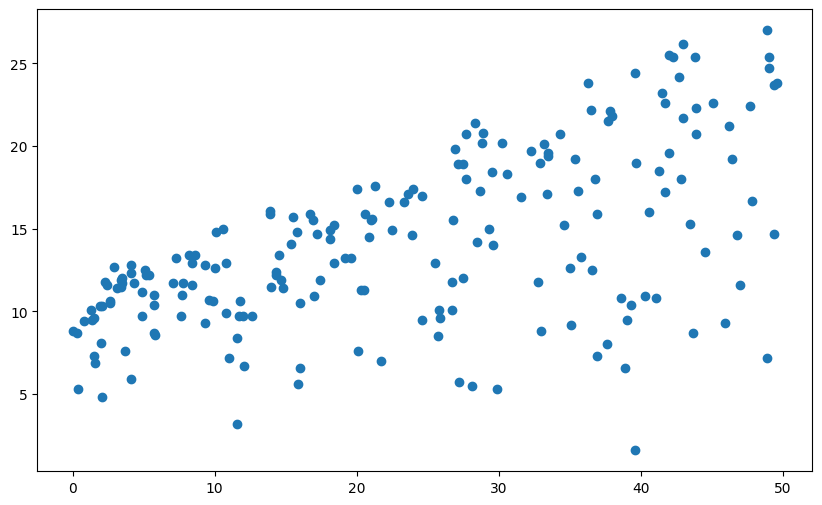

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['radio'], df['sales'])
plt.show()

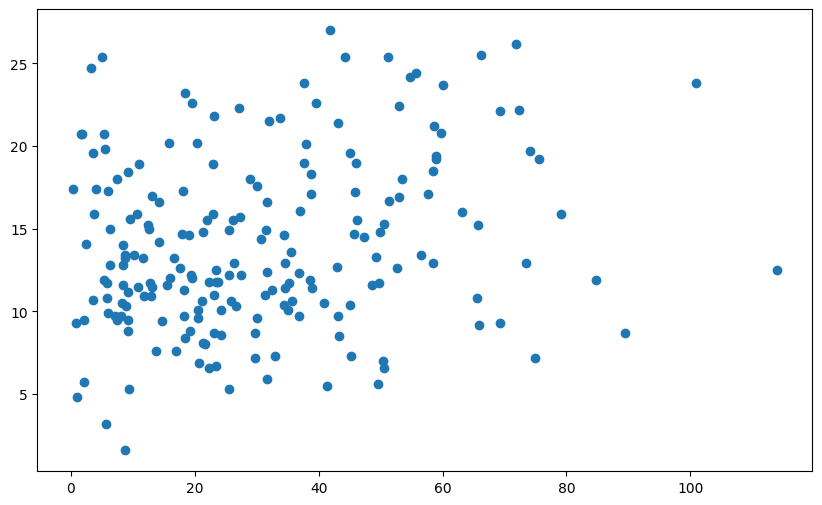

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['newspaper'], df['sales'])
plt.show()

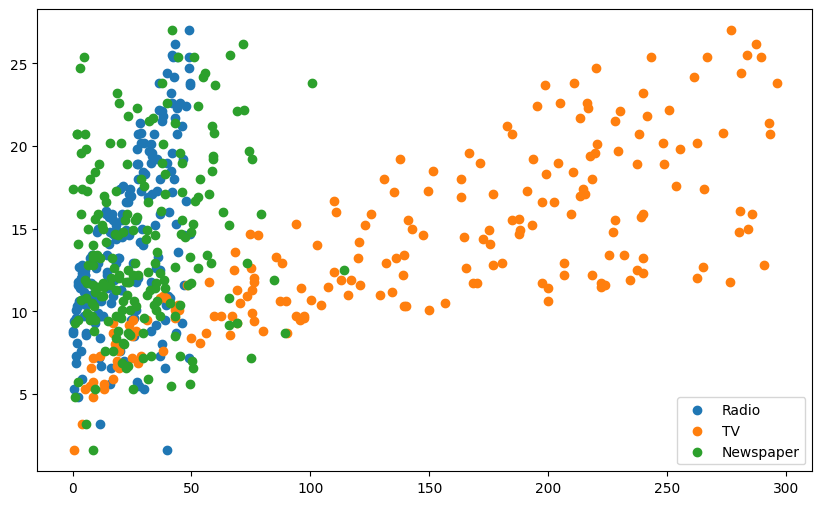

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(df['radio'], df['sales'], label='Radio')
plt.scatter(df['TV'], df['sales'], label='TV')
plt.scatter(df['newspaper'], df['sales'], label='Newspaper')
plt.legend()
plt.show()

In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

lr = LinearRegression()
arr1 = np.reshape(df['TV'], [-1,1])
lr.fit(arr1, df['sales'])
print(lr.intercept_, lr.coef_)

7.032593549127695 [0.04753664]


In [27]:
RSS = np.sum((df['sales'] - lr.predict(arr1))**2)
sigma2 = RSS / (len(arr1) - 2)
B0_SE = np.sqrt(sigma2 * (1/len(arr1) + (np.mean(arr1)**2 / np.sum((arr1 - np.mean(arr1))**2))))
B1_SE = np.sqrt(sigma2 / np.sum((arr1 - np.mean(arr1))**2))

print(f'Intervalo para B0: [{lr.intercept_ - 1.96 * B0_SE}, {lr.intercept_ + 1.96 * B0_SE}]')
print (f'Intervalo para B1: [{lr.coef_[0] - 1.96 * B1_SE}, {lr.coef_[0] + 1.96 * B1_SE}]')
print(B0_SE, B1_SE,sigma2)

Intervalo para B0: [6.135221386191677, 7.929965712063712]
Intervalo para B1: [0.04226305034493788, 0.05281023052110162]
0.4578429402734785 0.0026906071877968707 10.618841328946218


In [25]:
t_B0 = lr.intercept_ / B0_SE
t_B1 = lr.coef_[0] / B1_SE

print(f't_B0: {t_B0}, t_B1: {t_B1}')

t_B0: 15.360275174117547, t_B1: 17.667625600875546


In [26]:
from scipy import stats
p_B1 = 2 * (1 - stats.t.cdf(np.abs(t_B1), df=len(arr1)-2))
p_B0 = 2 * (1 - stats.t.cdf(np.abs(t_B0), df=len(arr1)-2))
print(f'p_B0: {p_B0}, p_B1: {p_B1}')

p_B0: 0.0, p_B1: 0.0
